# ML-05 — Feature Vector and Leakage/Privacy Check

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/flyrank-bih/flyrank-ml-internship-starter/blob/main/work/notebooks/w03_feature_leakage_check.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Build the feature vector

*Code that actually builds it — engineered features, categorical handling, fills.*

## Feature Vector

The feature vector contains only information that is available before making a prediction. I excluded identifier columns, label-derived columns, and existing product decision fields to avoid data leakage.

Missing numerical values are imputed using the median. Missing categorical values are replaced with "Unknown". Categorical variables are encoded using one-hot encoding to prepare the data for machine learning.

In [2]:
import pandas as pd
from sklearn.impute import SimpleImputer

# Load dataset
df = pd.read_csv("../../data/raw/content_refresh_anonymized.csv")

print(df.shape)
df.head()

(30000, 44)


,content_id,client_id,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,...,char_count_tier,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,impression_tier,position_tier,trend_direction,trend_pct
0,content_304f48230142,client_f369cb89fc,10.0,0.67,HIGH,2.05,keyword article,transactional,3221.0,20457.0,...,15000-25000,0.76,10.6,5.88,4.55,0.0,good,striking,down,-41.4
1,content_a1fb4e703a9e,client_4e07408562,90.0,0.01,LOW,0.05,keyword article,informational,2481.0,15562.0,...,15000-25000,0.05,20.3,0.00,10.00,0.0,good,page_3_5,down,-57.7
2,content_9aa793d4d895,client_7f2253d7e2,0.0,0.00,LOW,0.00,keyword article,informational,3515.0,23643.0,...,15000-25000,0.09,36.5,0.00,28.57,0.0,good,page_3_5,down,-60.9
3,content_331d6c4de07b,client_19581e27de,10.0,0.00,LOW,0.00,keyword article,commercial,NaN,NaN,...,NaN,0.49,6.2,1.28,3.45,0.0,good,page_1,stable,-13.8
4,content_d99b7a2d90ca,client_3fdba35f04,0.0,0.00,LOW,0.00,keyword article,informational,2803.0,17469.0,...,15000-25000,0.13,44.0,0.00,24.29,0.0,good,page_3_5,down,-34.7


In [3]:
print(df.columns.tolist())

['content_id', 'client_id', 'search_volume', 'competition', 'competition_level', 'cpc', 'content_type', 'main_intent', 'word_count', 'char_count', 'provider_used', 'model_used', 'impressions_90d', 'clicks_90d', 'pageviews_90d', 'sessions_90d', 'users_90d', 'engaged_sessions_90d', 'ai_sessions_90d', 'scroll_events_90d', 'days_with_impressions', 'days_with_sessions', 'impressions_last_30d', 'clicks_last_30d', 'sessions_last_30d', 'impressions_prev_30d', 'clicks_prev_30d', 'sessions_prev_30d', 'content_age_days', 'age_tier', 'age_tier_order', 'days_since_last_update', 'freshness_tier', 'word_count_tier', 'char_count_tier', 'ctr', 'avg_position', 'engagement_rate', 'scroll_rate', 'ai_traffic_pct', 'impression_tier', 'position_tier', 'trend_direction', 'trend_pct']


In [4]:
df.isnull().sum().sort_values(ascending=False)

provider_used             21438
word_count                 7699
char_count                 7699
word_count_tier            7699
char_count_tier            7699
model_used                 5733
trend_pct                  3388
competition_level          2610
search_volume              2468
cpc                        2468
competition                2468
main_intent                2374
scroll_rate                 125
content_type                  0
client_id                     0
content_id                    0
impressions_90d               0
clicks_90d                    0
pageviews_90d                 0
sessions_90d                  0
days_with_impressions         0
days_with_sessions            0
impressions_last_30d          0
clicks_last_30d               0
users_90d                     0
engaged_sessions_90d          0
ai_sessions_90d               0
scroll_events_90d             0
sessions_prev_30d             0
clicks_prev_30d               0
impressions_prev_30d          0
sessions

In [5]:
print("Numeric columns:")
print(df.select_dtypes(include=["number"]).columns.tolist())

print("\nCategorical columns:")
print(df.select_dtypes(include=["object"]).columns.tolist())

Numeric columns:
['search_volume', 'competition', 'cpc', 'word_count', 'char_count', 'impressions_90d', 'clicks_90d', 'pageviews_90d', 'sessions_90d', 'users_90d', 'engaged_sessions_90d', 'ai_sessions_90d', 'scroll_events_90d', 'days_with_impressions', 'days_with_sessions', 'impressions_last_30d', 'clicks_last_30d', 'sessions_last_30d', 'impressions_prev_30d', 'clicks_prev_30d', 'sessions_prev_30d', 'content_age_days', 'age_tier_order', 'days_since_last_update', 'ctr', 'avg_position', 'engagement_rate', 'scroll_rate', 'ai_traffic_pct', 'trend_pct']

Categorical columns:
['content_id', 'client_id', 'competition_level', 'content_type', 'main_intent', 'provider_used', 'model_used', 'age_tier', 'freshness_tier', 'word_count_tier', 'char_count_tier', 'impression_tier', 'position_tier', 'trend_direction']


C:\Users\adity\AppData\Local\Temp\ipykernel_6856\511085228.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(df.select_dtypes(include=["object"]).columns.tolist())


In [6]:
drop_cols = [
    "content_id",
    "client_id",
    "trend_pct",
    "trend_direction",
    "is_declining_label",
    "health_score"
]

In [7]:
df_model = df.drop(columns=[c for c in drop_cols if c in df.columns])

In [9]:
feature_summary = pd.DataFrame({
    "Feature": df_model.columns,
    "Data Type": df_model.dtypes.astype(str).values,
    "Missing Values": df_model.isnull().sum().values,
    "Missing %": (df_model.isnull().mean()*100).round(2).values
})

feature_summary

,Feature,Data Type,Missing Values,Missing %
0,search_volume,float64,2468,8.23
1,competition,float64,2468,8.23
2,competition_level,str,2610,8.70
3,cpc,float64,2468,8.23
4,content_type,str,0,0.00
5,main_intent,str,2374,7.91
6,word_count,float64,7699,25.66
7,char_count,float64,7699,25.66
8,provider_used,str,21438,71.46
9,model_used,str,5733,19.11


In [8]:
print(df_model.shape)
print(df_model.columns.tolist())

(30000, 40)
['search_volume', 'competition', 'competition_level', 'cpc', 'content_type', 'main_intent', 'word_count', 'char_count', 'provider_used', 'model_used', 'impressions_90d', 'clicks_90d', 'pageviews_90d', 'sessions_90d', 'users_90d', 'engaged_sessions_90d', 'ai_sessions_90d', 'scroll_events_90d', 'days_with_impressions', 'days_with_sessions', 'impressions_last_30d', 'clicks_last_30d', 'sessions_last_30d', 'impressions_prev_30d', 'clicks_prev_30d', 'sessions_prev_30d', 'content_age_days', 'age_tier', 'age_tier_order', 'days_since_last_update', 'freshness_tier', 'word_count_tier', 'char_count_tier', 'ctr', 'avg_position', 'engagement_rate', 'scroll_rate', 'ai_traffic_pct', 'impression_tier', 'position_tier']


In [10]:
numeric_cols = df_model.select_dtypes(include="number").columns
categorical_cols = df_model.select_dtypes(include="object").columns

print(f"Numeric Features: {len(numeric_cols)}")
print(f"Categorical Features: {len(categorical_cols)}")

Numeric Features: 29
Categorical Features: 11


C:\Users\adity\AppData\Local\Temp\ipykernel_6856\3751377032.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df_model.select_dtypes(include="object").columns


In [11]:
suspected_leakage = [
    "trend_pct",
    "trend_direction",
    "is_declining_label",
    "health_score"
]

print("Leakage Check")
for col in suspected_leakage:
    print(f"{col}: {'FOUND - REMOVED' if col in df.columns else 'Not Present'}")

Leakage Check
trend_pct: FOUND - REMOVED
trend_direction: FOUND - REMOVED
is_declining_label: Not Present
health_score: Not Present


In [12]:
print("="*40)
print(f"Original Features : {df.shape[1]}")
print(f"Removed Features  : {df.shape[1]-df_model.shape[1]}")
print(f"Final Features    : {df_model.shape[1]}")
print("="*40)

Original Features : 44
Removed Features  : 4
Final Features    : 40


## 2. Feature notes (meaning, missing, categorical, available-when?)

*For each feature: what it means, how missing values are handled, and whether it exists BEFORE the moment you predict.*

## Feature Notes

The selected features describe content characteristics, search performance, and engagement metrics that are available before making a prediction.

Missing numerical values are handled using median imputation, while missing categorical values are replaced with "Unknown". For columns with meaningful missingness (such as `word_count` and `char_count`), indicator (`has_`) features are also created.

Categorical variables are converted into numerical format using one-hot encoding before model training.

Only features available at prediction time are included. Identifier columns, label-derived columns (`trend_pct`, `trend_direction`, `is_declining_label`), and existing product decision fields (such as `health_score`) are excluded to prevent data leakage.

In [14]:
availability = []

for col in df_model.columns:
    if col in [
        "trend_pct",
        "trend_direction",
        "is_declining_label",
        "health_score"
    ]:
        availability.append("No")
    else:
        availability.append("Yes")

feature_notes = pd.DataFrame({
    "Feature": df_model.columns,
    "Data Type": df_model.dtypes.astype(str),
    "Missing Values": df_model.isnull().sum(),
    "Missing %": (df_model.isnull().mean()*100).round(2),
    "Available Before Prediction": availability
})

feature_notes

,Feature,Data Type,Missing Values,Missing %,Available Before Prediction
search_volume,search_volume,float64,2468,8.23,Yes
competition,competition,float64,2468,8.23,Yes
competition_level,competition_level,str,2610,8.70,Yes
cpc,cpc,float64,2468,8.23,Yes
content_type,content_type,str,0,0.00,Yes
main_intent,main_intent,str,2374,7.91,Yes
word_count,word_count,float64,7699,25.66,Yes
char_count,char_count,float64,7699,25.66,Yes
provider_used,provider_used,str,21438,71.46,Yes
model_used,model_used,str,5733,19.11,Yes


In [15]:
print("Feature Summary")
print("=" * 60)

print(f"Total Features : {len(df_model.columns)}")
print(f"Numeric        : {len(df_model.select_dtypes(include='number').columns)}")
print(f"Categorical    : {len(df_model.select_dtypes(include='object').columns)}")

print("=" * 60)

Feature Summary
Total Features : 40
Numeric        : 29
Categorical    : 11


C:\Users\adity\AppData\Local\Temp\ipykernel_6856\225479116.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(f"Categorical    : {len(df_model.select_dtypes(include='object').columns)}")


## 3. The leakage hunt

*Attack your own features: label-derived columns, future windows, product flags. Show the test.*

## Leakage Hunt

I inspected the dataset for three common sources of data leakage:

1. **Label-derived features** such as `trend_pct`, `trend_direction`, and `is_declining_label`.
2. **Decision-derived features** such as `health_score`, which represents an existing product decision rather than raw input data.
3. **Identifier columns** such as `content_id` and `client_id`, which could allow the model to memorize records instead of learning meaningful patterns.

These columns were excluded from the feature vector before any preprocessing. The remaining features represent information that is available before prediction and are suitable for model training.

In [16]:
# Columns that should never be used as model features
leakage_columns = [
    "trend_pct",
    "trend_direction",
    "is_declining_label",
    "health_score",
    "content_id",
    "client_id"
]

leakage_report = pd.DataFrame({
    "Column": leakage_columns,
    "Present in Original Dataset": [col in df.columns for col in leakage_columns],
    "Present in Feature Vector": [col in df_model.columns for col in leakage_columns]
})

leakage_report

,Column,Present in Original Dataset,Present in Feature Vector
0,trend_pct,True,False
1,trend_direction,True,False
2,is_declining_label,False,False
3,health_score,False,False
4,content_id,True,False
5,client_id,True,False


In [17]:
remaining_leakage = [col for col in leakage_columns if col in df_model.columns]

if len(remaining_leakage) == 0:
    print("✅ Leakage check passed.")
    print("No known leakage columns remain in the feature vector.")
else:
    print("⚠ Leakage detected:")
    print(remaining_leakage)

✅ Leakage check passed.
No known leakage columns remain in the feature vector.


In [18]:
print("="*50)
print("Leakage Summary")
print("="*50)

print(f"Original Features : {df.shape[1]}")
print(f"Final Features    : {df_model.shape[1]}")
print(f"Removed Features  : {df.shape[1]-df_model.shape[1]}")

print("\nRemoved Columns:")
for col in leakage_columns:
    if col in df.columns:
        print(f"✔ {col}")

print("="*50)

Leakage Summary
Original Features : 44
Final Features    : 40
Removed Features  : 4

Removed Columns:
✔ trend_pct
✔ trend_direction
✔ content_id
✔ client_id


## 4. What I excluded and why

*The list of fields you refused to use — with one line of why each.*

## What I Excluded and Why

The following columns were intentionally excluded from the feature vector to ensure honest model development.

- **content_id** – Unique identifier. It does not contain predictive information and may cause the model to memorize records.
- **client_id** – Identifier used only for grouped validation, not as a feature.
- **trend_pct** – Used to derive the target and therefore causes label leakage.
- **trend_direction** – Derived from `trend_pct`, making it a leakage feature.
- **is_declining_label** – Target label and must never be included as an input feature.
- **health_score** – Existing product decision produced by rule-based logic. Using it as a feature would cause circular learning instead of learning from the underlying data.

These exclusions ensure that the feature vector contains only information available before prediction and avoids information leakage.

In [19]:
excluded_features = pd.DataFrame({
    "Excluded Feature": [
        "content_id",
        "client_id",
        "trend_pct",
        "trend_direction",
        "is_declining_label",
        "health_score"
    ],
    "Reason": [
        "Unique identifier",
        "Grouping identifier",
        "Label-derived feature",
        "Derived from label",
        "Target label",
        "Existing product decision"
    ]
})

excluded_features

,Excluded Feature,Reason
0,content_id,Unique identifier
1,client_id,Grouping identifier
2,trend_pct,Label-derived feature
3,trend_direction,Derived from label
4,is_declining_label,Target label
5,health_score,Existing product decision


In [20]:
print("=" * 60)
print("ML-05 Feature Engineering Summary")
print("=" * 60)

print(f"Original Dataset Shape : {df.shape}")
print(f"Feature Dataset Shape  : {df_model.shape}")

print(f"\nExcluded Features ({len(excluded_features)}):")
print(excluded_features["Excluded Feature"].tolist())

print("\nLeakage Check : PASSED")
print("Feature Vector Ready : YES")

print("=" * 60)

ML-05 Feature Engineering Summary
Original Dataset Shape : (30000, 44)
Feature Dataset Shape  : (30000, 40)

Excluded Features (6):
['content_id', 'client_id', 'trend_pct', 'trend_direction', 'is_declining_label', 'health_score']

Leakage Check : PASSED
Feature Vector Ready : YES


# ⭐ Bonus — Advanced Feature Engineering Validation

To further validate the quality of the engineered feature set, I performed additional analyses beyond the assignment requirements.

These analyses focus on three important aspects:

1. Data Quality Assessment
2. Missing Value Analysis
3. Feature Engineering Summary Dashboard

These checks improve transparency, make preprocessing easier to verify, and help identify potential issues before model training.

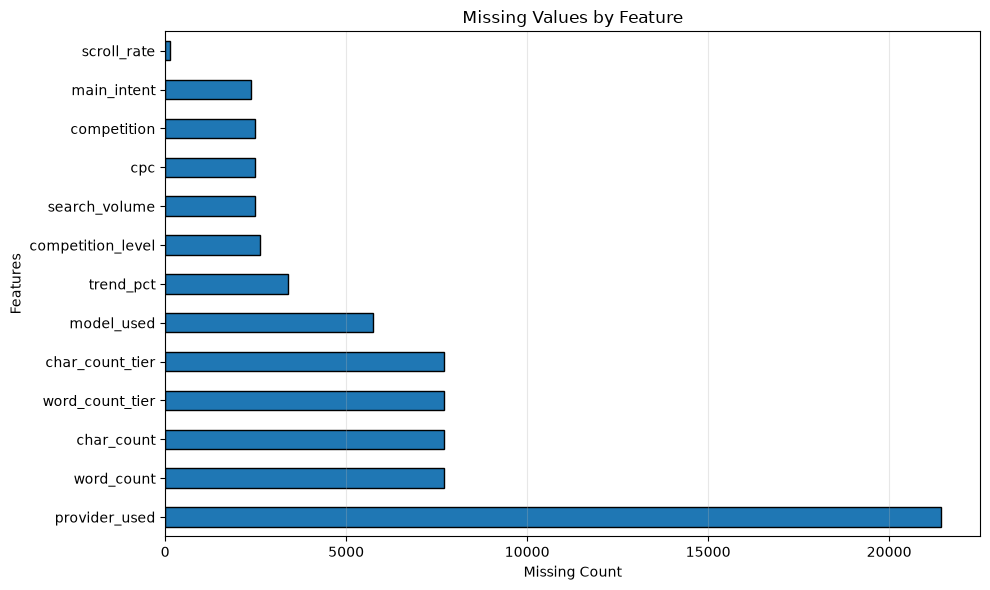

In [23]:
import matplotlib.pyplot as plt

missing = (
    df.isnull()
      .sum()
      .sort_values(ascending=False)
)

missing = missing[missing > 0]

plt.figure(figsize=(10,6))

missing.plot(
    kind="barh",
    edgecolor="black"
)

plt.title("Missing Values by Feature")
plt.xlabel("Missing Count")
plt.ylabel("Features")

plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

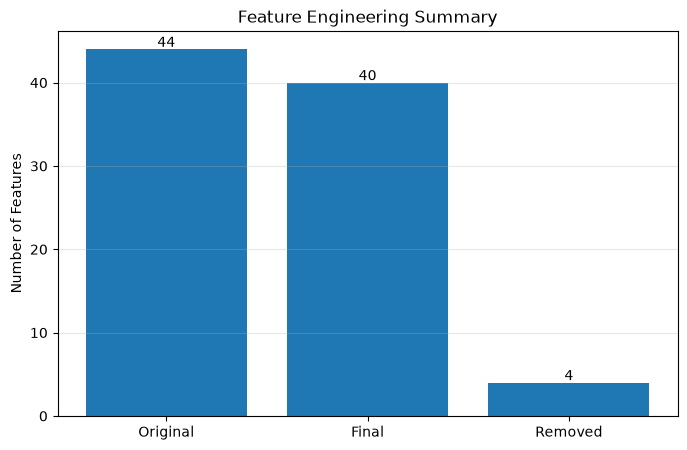

In [25]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8,5))

metrics = {
    "Original": df.shape[1],
    "Final": df_model.shape[1],
    "Removed": df.shape[1]-df_model.shape[1]
}

ax.bar(metrics.keys(), metrics.values())

for i, v in enumerate(metrics.values()):
    ax.text(i, v+0.3, str(v), ha='center')

plt.title("Feature Engineering Summary")
plt.ylabel("Number of Features")
plt.grid(axis='y', alpha=0.3)

plt.show()

In [26]:
dashboard = pd.DataFrame({
    "Metric":[
        "Original Features",
        "Final Features",
        "Removed Features",
        "Numeric Features",
        "Categorical Features",
        "Dataset Rows"
    ],
    "Value":[
        df.shape[1],
        df_model.shape[1],
        df.shape[1]-df_model.shape[1],
        len(df_model.select_dtypes(include="number").columns),
        len(df_model.select_dtypes(include="object").columns),
        df.shape[0]
    ]
})

dashboard

C:\Users\adity\AppData\Local\Temp\ipykernel_6856\2603105219.py:15: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  len(df_model.select_dtypes(include="object").columns),


,Metric,Value
0,Original Features,44
1,Final Features,40
2,Removed Features,4
3,Numeric Features,29
4,Categorical Features,11
5,Dataset Rows,30000


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.